# Description

It selects a set of specific gene pairs from a tissue, and checks if relationship are replicated on other tissues.
It also uses GTEx metadata (such as sex) to explain relationships.

# Modules

In [1]:
import pandas as pd

from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

from ccc import conf
from ccc.coef import ccc

# Settings

In [2]:
# this gene pair was originally found with ccc on whole blood
# interesting: https://clincancerres.aacrjournals.org/content/26/21/5567.figures-only
gene0_id, gene1_id = "ENSG00000147050.14", "ENSG00000183878.15"
gene0_symbol, gene1_symbol = "KDM6A", "UTY"

# Paths

In [3]:
TISSUE_DIR = conf.GTEX["DATA_DIR"] / "data_by_tissue"
assert TISSUE_DIR.exists()

In [4]:
OUTPUT_FIGURE_DIR = (
    conf.MANUSCRIPT["FIGURES_DIR"]
    / "coefs_comp"
    / f"{gene0_symbol.lower()}_vs_{gene1_symbol.lower()}"
)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_FIGURE_DIR)

PosixPath('/opt/manuscript/content/images/coefs_comp/kdm6a_vs_uty')

# Data

## GTEx metadata

In [5]:
gtex_metadata = pd.read_pickle(conf.GTEX["DATA_DIR"] / "gtex_v8-sample_metadata.pkl")

In [6]:
gtex_metadata.shape

(22951, 66)

In [7]:
gtex_metadata.head()

,SUBJID,SEX,AGE,DTHHRDY,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
SAMPID,,,,,,,,,,,,,,,,,,,,,
GTEX-1117F-0003-SM-58Q7G,GTEX-1117F,Female,60-69,4.0,NaN,B1,NaN,NaN,Blood,Whole Blood,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTEX-1117F-0003-SM-5DWSB,GTEX-1117F,Female,60-69,4.0,NaN,B1,NaN,NaN,Blood,Whole Blood,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTEX-1117F-0003-SM-6WBT7,GTEX-1117F,Female,60-69,4.0,NaN,B1,NaN,NaN,Blood,Whole Blood,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTEX-1117F-0011-R10a-SM-AHZ7F,GTEX-1117F,Female,60-69,4.0,NaN,"B1, A1",NaN,NaN,Brain,Brain - Frontal Cortex (BA9),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GTEX-1117F-0011-R10b-SM-CYKQ8,GTEX-1117F,Female,60-69,4.0,NaN,"B1, A1",NaN,7.2,Brain,Brain - Frontal Cortex (BA9),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Gene Ensembl ID -> Symbol mapping

In [8]:
gene_map = pd.read_pickle(conf.GTEX["DATA_DIR"] / "gtex_gene_id_symbol_mappings.pkl")

In [9]:
gene_map = gene_map.set_index("gene_ens_id")["gene_symbol"].to_dict()

In [10]:
assert gene_map["ENSG00000145309.5"] == "CABS1"

In [11]:
assert gene_map[gene0_id] == gene0_symbol
assert gene_map[gene1_id] == gene1_symbol

# Plot

In [24]:
def get_tissue_file(name):
    """
    Given a part of a tissue name, it returns a file path to the
    expression data for that tissue in GTEx. It fails if more than
    one files are found.

    Args:
        name: a string with the tissue name (or a part of it).

    Returns:
        A Path object pointing to the gene expression file for the
        given tissue.
    """
    tissue_files = []
    for f in TISSUE_DIR.glob("*.pkl"):
        if name in f.name:
            tissue_files.append(f)

    assert len(tissue_files) == 1
    return tissue_files[0]

In [25]:
# testing
_tmp = get_tissue_file("whole_blood")
assert _tmp.exists()

In [26]:
def simplify_tissue_name(tissue_name):
    return f"{tissue_name[0].upper()}{tissue_name[1:].replace('_', ' ')}"

In [27]:
assert simplify_tissue_name("whole_blood") == "Whole blood"
assert simplify_tissue_name("uterus") == "Uterus"

In [28]:
def plot_gene_pair(
    tissue_name, gene0, gene1, hue=None, kind="hex", ylim=None, bins="log"
):
    """
    It plots (joint plot) a gene pair from the given tissue. It saves the plot
    for the manuscript.
    """
    # merge gene expression with metadata
    tissue_file = get_tissue_file(tissue_name)
    tissue_data = pd.read_pickle(tissue_file).T[[gene0, gene1]]
    tissue_data = pd.merge(
        tissue_data,
        gtex_metadata,
        how="inner",
        left_index=True,
        right_index=True,
        validate="one_to_one",
    )

    # get gene symbols
    gene0_symbol, gene1_symbol = gene_map[gene0], gene_map[gene1]
    display((gene0_symbol, gene1_symbol))

    # compute correlations for this gene pair
    _clustermatch = ccc(tissue_data[gene0], tissue_data[gene1])
    _pearson = pearsonr(tissue_data[gene0], tissue_data[gene1])[0]
    _spearman = spearmanr(tissue_data[gene0], tissue_data[gene1])[0]

    _title = f"{simplify_tissue_name(tissue_name)}\n$c={_clustermatch:.2f}$  $p={_pearson:.2f}$  $s={_spearman:.2f}$"

    other_args = {
        "kind": kind,  # if hue is None else "scatter",
        "rasterized": True,
    }
    if hue is None:
        # other_args["bins"] = bins
        pass
    else:
        other_args["hue_order"] = ["Male", "Female"]

    with sns.plotting_context("paper", font_scale=1.5):
        p = sns.jointplot(
            data=tissue_data,
            x=gene0,
            y=gene1,
            hue=hue,
            **other_args,
            # ylim=(0, 500),
        )

        if ylim is not None:
            p.ax_joint.set_ylim(ylim)

        gene_x_id = p.ax_joint.get_xlabel()
        gene_x_symbol = gene_map[gene_x_id]
        p.ax_joint.set_xlabel(f"{gene_x_symbol}", fontstyle="italic")

        gene_y_id = p.ax_joint.get_ylabel()
        gene_y_symbol = gene_map[gene_y_id]
        p.ax_joint.set_ylabel(f"{gene_y_symbol}", fontstyle="italic")

        p.fig.suptitle(_title)

        # save
        output_file = (
            OUTPUT_FIGURE_DIR
            / f"gtex_{tissue_name}-{gene_x_symbol}_vs_{gene_y_symbol}.png"
        )
        # display(output_file)

        plt.savefig(
            output_file,
            bbox_inches="tight",
            dpi=300,
            facecolor="white",
        )
        
        # display(p)

    return p, output_file

## Read Haoyu gene pairs

In [29]:
list(conf.DATA_DIR.glob("*"))

[PosixPath('/opt/data/data/haoyu_gene_pairs.txt'),
 PosixPath('/opt/data/data/gtex_v8')]

In [30]:
hgp = pd.read_csv(conf.DATA_DIR / "haoyu_gene_pairs.txt", sep="\s+")

In [31]:
hgp.columns

Index(['Index', 'Pearson', '(high)', 'Pearson.1', '(low)', 'Spearman',
       '(high).1', 'Spearman.1', '(low).1', 'Clustermatch', '(high).2',
       'Clustermatch.1', '(low).2', 'ccc', 'pearson', 'spearman',
       'ccc_pearson_diff', 'ccc_spearman_diff', 'ccc_combined_distance',
       'ccc_mean_distance', 'ccc_max_distance'],
      dtype='object')

In [32]:
hgp.head()

,Index,Pearson,(high),Pearson.1,(low),Spearman,(high).1,Spearman.1,(low).1,Clustermatch,...,Clustermatch.1,(low).2,ccc,pearson,spearman,ccc_pearson_diff,ccc_spearman_diff,ccc_combined_distance,ccc_mean_distance,ccc_max_distance
0,"('ENSG00000189067.12',",'ENSG00000100226.15'),F,T,F,T,T,F,0.112427,0.007744,...,0.105,0.095,0.200,0.100,0.105,NaN,NaN,NaN,NaN,NaN
1,"('ENSG00000130816.14',",'ENSG00000238227.7'),F,T,F,T,T,F,0.109314,0.014679,...,0.095,0.106,0.201,0.100,0.106,NaN,NaN,NaN,NaN,NaN
2,"('ENSG00000221829.9',",'ENSG00000159792.9'),F,T,F,T,T,F,0.115112,0.014847,...,0.100,0.100,0.201,0.100,0.100,NaN,NaN,NaN,NaN,NaN
3,"('ENSG00000182095.14',",'ENSG00000100226.15'),F,T,F,T,T,F,0.111633,0.015526,...,0.096,0.105,0.201,0.101,0.105,NaN,NaN,NaN,NaN,NaN
4,"('ENSG00000168488.18',",'ENSG00000106636.7'),F,T,F,T,T,F,0.113586,0.010529,...,0.103,0.099,0.202,0.101,0.103,NaN,NaN,NaN,NaN,NaN


In [33]:
i = 0
gene0_id, gene1_id = hgp.iloc[i,:2]
gene0_id = gene0_id.split("'")[1]
gene1_id = gene1_id.split("'")[1]
display(gene0_id, gene1_id)

'ENSG00000189067.12'

'ENSG00000100226.15'

In [86]:
from ollama import Client
client = Client(
  host='http://host.docker.internal:11434',
)

def analyze_figure(output_file):
    response = client.chat(
        # model='gemma3:27b',
        model='qwen2.5vl:32b',
        # model='qwen2.5vl:7b',
        messages=[
      {
        'role': 'user',
        'content':
        """
Analyze the image, which shows a scatter plot with a pattern between two genes.
Classify the pattern in one of these categories:
1. Two lines, one with positive slope and the other with negative slope.
2. Two lines, both with positive slope.
3. Other.
Respond only with the category name. Do not explain anything.
        """.strip(),
        'images': [output_file],
      },
    ])

    # print(response['message']['content'])
    # or access fields directly from the response object
    print(response.message.content)
    
    return response.message.content.strip()

In [87]:
# YES
analyze_figure(OUTPUT_FIGURE_DIR / "test" / "pattern0.png")
analyze_figure(OUTPUT_FIGURE_DIR / "test" / "pattern1.png")

[2025-07-17 19:35:06,275 - httpx] INFO: HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


Two lines, both with positive slope.


[2025-07-17 19:35:42,378 - httpx] INFO: HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


Other.


'Other.'

In [88]:
# NO
analyze_figure(OUTPUT_FIGURE_DIR / "test" / "pattern2.png")
analyze_figure(OUTPUT_FIGURE_DIR / "test" / "pattern3.png")
analyze_figure(OUTPUT_FIGURE_DIR / "test" / "pattern4.png")

[2025-07-17 19:36:21,162 - httpx] INFO: HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


Other.


KeyboardInterrupt: 

('LITAF', 'GTPBP1')

[2025-07-17 18:59:10,826 - httpx] INFO: HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


YES


('DNMT1', 'C9orf69')

[2025-07-17 18:59:11,649 - httpx] INFO: HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


...

[2025-07-17 18:59:17,604 - httpx] INFO: HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


YES


('OSBPL8', 'GZF1')

[2025-07-17 18:59:18,475 - httpx] INFO: HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


YES


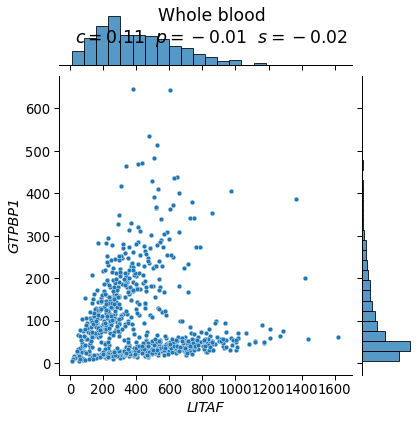

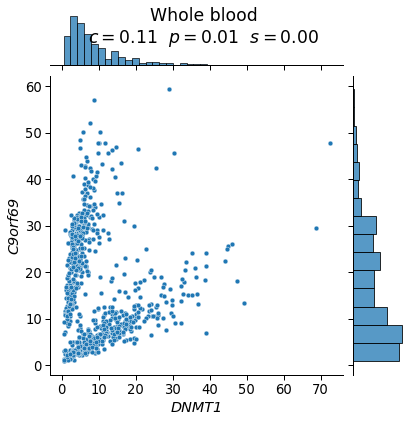

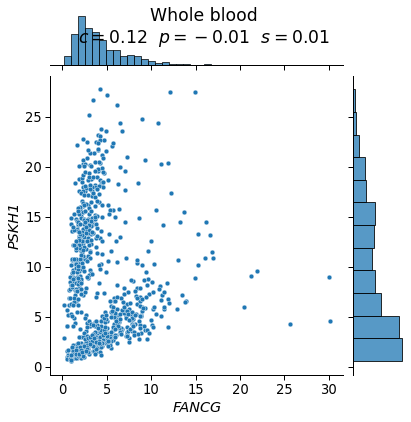

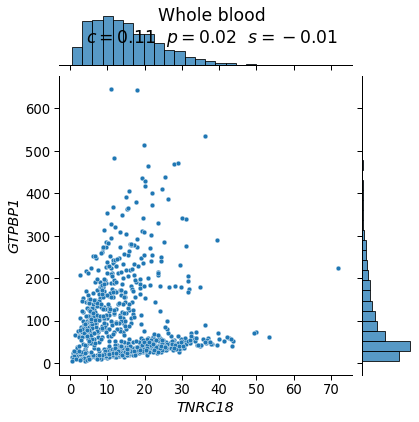

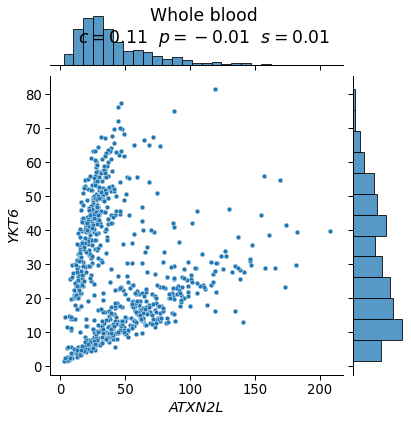

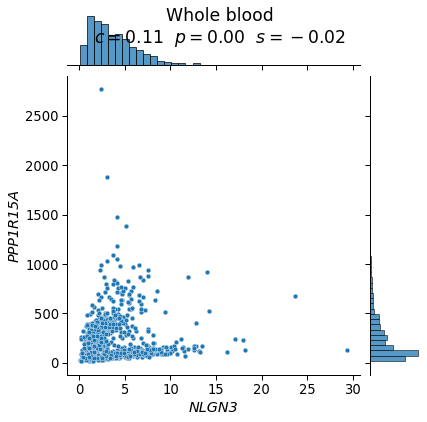

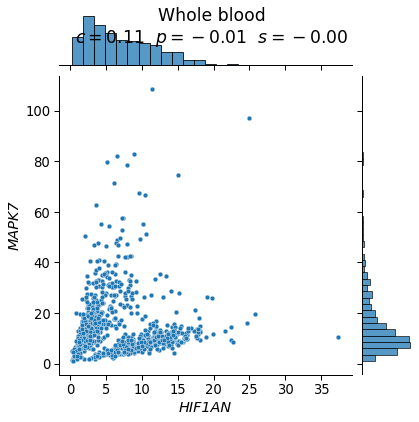

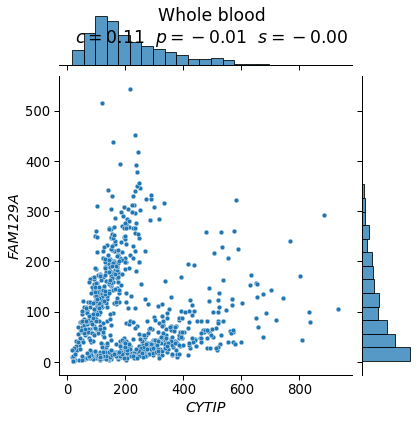

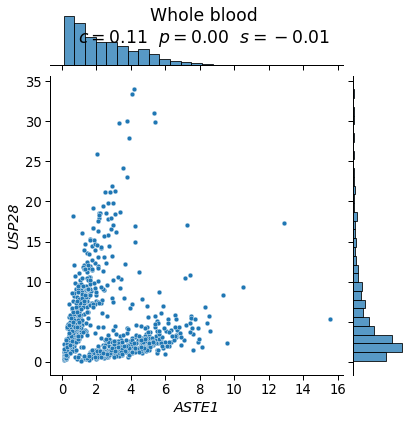

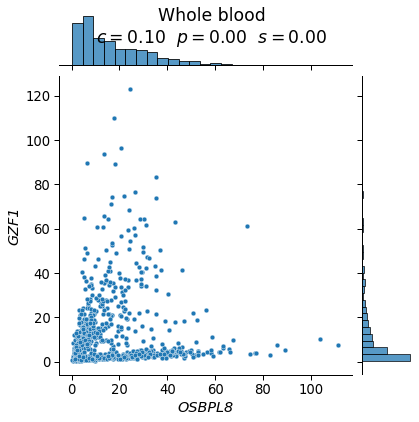

In [40]:
for i in range(0, 10):
    gene0_id, gene1_id = hgp.iloc[i,:2]
    gene0_id = gene0_id.split("'")[1]
    gene1_id = gene1_id.split("'")[1]
    # display(gene0_id, gene1_id)
    
    p, output_file = plot_gene_pair(
        "whole_blood",
        gene0_id,
        gene1_id,
        # hue="SEX",
        kind="scatter",
    )
    
    display(p)
    
    analyze_figure(output_file)